# Statistics

In [42]:
import pandas as pd
import seaborn as sns

In [7]:
list(range(4))

[0, 1, 2, 3]

**Example**: we will demonstrate using datasets accessible from the seaborn library. Once you call `load_dataset`, it will load it into a DataFrame.

In [43]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Distributions

The **Distribution** of a variable is the frequencies of its values

- For categorical variables (like `island`) they are just the **proportions** (relative counts)
- For numerical variables, we need **binning**; i.e., grouping ranges of numerical values into buckets (we'll see this when we plot it)

### Counts

Statistics starts with **Counts**; the number of subjects with a certain characteristic.

Example is the `value_counts()`, summarizing the count of each value in the variable column:

In [44]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

But we could also visualize it:

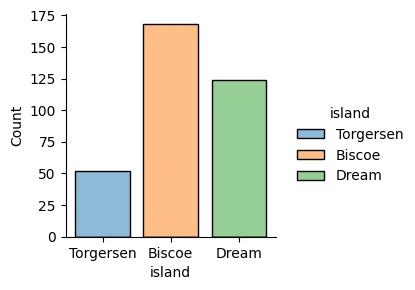

In [45]:
sns.displot(
    data=penguins, x='island', hue='island',
    discrete=True, # categorical
    shrink=0.8,
    height=3, aspect=1
)

### Proportions

When ccounts are relative to the whole, it is called **Proportion** ($\hat p$) or *Relative Frequency* and is often expressed in precentage (%).

$$
\hat{p} = \frac{n}{N}
$$

We can show this using `value_counts` with `normalize=True`, like so:

In [46]:
penguins['island'].value_counts(normalize=True)

island
Biscoe       0.488372
Dream        0.360465
Torgersen    0.151163
Name: proportion, dtype: float64

It can be expressed in seaborn `displot` by setting `stat="probability"`:

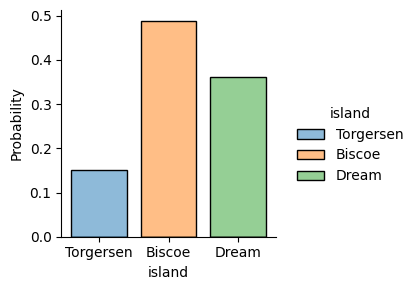

In [47]:
sns.displot(
    data=penguins, x='island', hue='island',
    discrete=True, # categorical
    shrink=0.8,
    height=3, aspect=1,
    stat='probability'  # Shows relative frequency
)

Notice how the bars are always proportional whether we are using counts or frequencies on the y-axis.

### Numerical Variable Distribution

Let's look at the NBA players dataset:

In [48]:
df = pd.read_csv('../../data/nba_heights.csv')
df.head()

,last_name,first_name,h_meters,h_in
0,Acker,Alex,1.96,77
1,Adams,Hassan,1.93,76
2,Afflalo,Arron,1.96,77
3,Ager,Maurice,1.96,77
4,Ajinca,Alexis,2.13,84


Let's look at the value counts of height in meters `h_meters` (numerical):

In [49]:
counts = df['h_meters'].value_counts()
counts.nlargest(10)

h_meters
2.06    58
2.03    43
2.08    43
2.01    41
2.11    39
1.91    35
1.98    34
2.13    33
1.96    28
1.88    21
Name: count, dtype: int64

### Binning

In [116]:
bins = pd.cut(df['h_meters'], bins=7)
bin_counts = bins.value_counts().sort_index()
bin_counts

h_meters
(1.749, 1.827]      5
(1.827, 1.904]     47
(1.904, 1.981]    114
(1.981, 2.059]     84
(2.059, 2.136]    173
(2.136, 2.213]     11
(2.213, 2.29]       1
Name: count, dtype: int64

### Visualizing Numerical Distribution: Histogram

We can visualize the count of their heights with a **Histogram**, which is one type of *Distribution Plot*; named as such because it shows where the values of the variable `height` lie on the x-axis, and how many of them are there (count).

Instead of showing all the values, we group them into **Bins** of uniform size, and represent how many values in the bin, vertically, by the height of bin itself.

This is the simplest and most useful type of statistical plot. In seaborn, it is `displot` (distribution plot), like so:

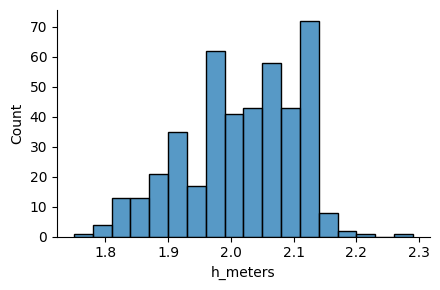

In [100]:
sns.displot(df, x='h_meters',
    aspect=1.5, height=3
)

Sometimes we use the **Kernel Density Estimation plot** (KDE) instead to show the distrubtion:

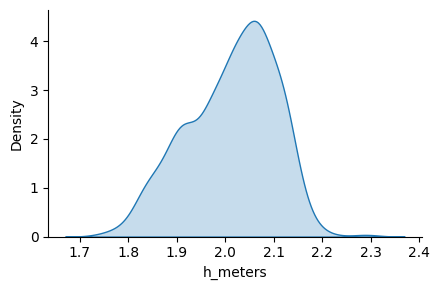

In [118]:
import matplotlib.pyplot as plt

sns.displot(df, x='h_meters',
    kind='kde', fill=True,
    aspect=1.5, height=3
)

## Distribution Statistics

We describe a distribtuion by three properties:

1. **Central Tendency**
2. **Dispersion**
3. **Skewness**

### 1. Central Tendency

 1. **Mode**: the most frequent value.
 2. **Median**: the middle value when data are ordered.
 3. **Mean** (average): the center of "mass" ($\bar{x}$ or $\mu$).

The mean ($\mu$) is the sum of the values divided by their count:

$$
\mu = \frac{1}{N}\sum_{i=1}^{N} x_i
$$

- $\mu$ denotes population mean
- $N$ is the count

### 2. Dispersion

  1. **Range**: the difference between the maximum and minimum values.
  2. **Variance**: the average of the squared differences from the mean ($\sigma^2$).
  3. **Standard Deviation**: the square root of the variance ($\sigma$).

The variance ($\sigma^2$) is described mathematically as:

$$
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2
$$

In a physical sense, we can see:

- the variance being the spread of the mass
- the mean being the center of the mass

![Physical Metaphor](../../assets/variance_physical_metaphor.png)

In Pandas, we simply call the `describe` method on the column (series), to get all these statistics:

In [121]:
df['h_meters'].describe()

count    435.000000
mean       2.012483
std        0.090078
min        1.750000
25%        1.960000
50%        2.030000
75%        2.080000
max        2.290000
Name: h_meters, dtype: float64

Note the following:

- The `std` is the standard deviation
- The `50%` percentile is the **median** statistic.
- The **range** is shown by the **max** and **min** statistics.
- The **mode** is more useful when we are looking at categorical attribute. In our case, the attribute is numerical.

### Percentiles

The **median** is the 50th percentile (`50%`) which means that 50% of the data points are below this value.

The `25%` and the `75%` percentiles go by other names:
  - the 1st and 3rd quartiles
  - the Q1 and Q3
  - the lower and upper quartiles

### 3. Skewness

We get skewness when the distribution is **not symmetric**:

- The *Mode* is the peak
- The *Mean* pulls the curve downwards
- The *Median* follows the mean a little bit

![Skewness](../../assets/skewness.png){height=480}

This can be calculated using the `.skew()` method where:

- `0` Perfectly Symmetrical (Normal).
- `>0` Right-skewed: Long tail on the right side.
- `<0` Left-skewed: Long tail on the left side.

In [122]:
df['h_meters'].skew()

np.float64(-0.39538985680696676)

## Comparing Distributions: NBA vs the rest

In [62]:
# Source NBA Heights: https://github.com/simonwarchol/NBA-Height-Weight/blob/master/CSVs/total.csv
nba = pd.read_csv('../../data/nba_heights.csv')
nba.describe()

,h_meters,h_in
count,435.000000,435.000000
mean,2.012483,79.209195
std,0.090078,3.573444
min,1.750000,69.000000
25%,1.960000,77.000000
50%,2.030000,80.000000
75%,2.080000,82.000000
max,2.290000,90.000000


In [63]:
# Source Human Heights: https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset
humans = pd.read_csv('../../data/SOCR-HeightWeight.csv')
humans.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


- We will draw both distributions on the same plot, with different colors for comparison.
- The vertical line is the **mean**

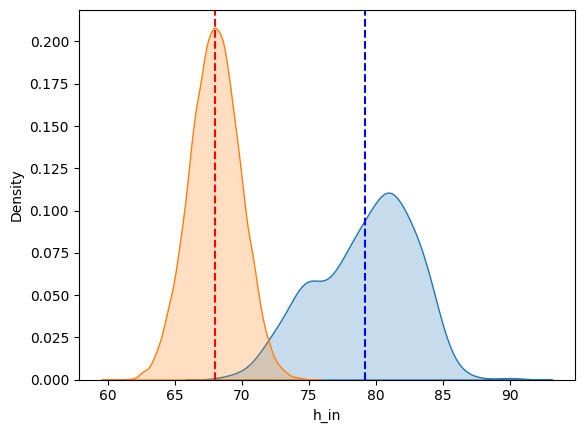

In [111]:
# Plot the distributions of both on the same plot
sns.kdeplot(nba, x='h_in', fill=True)
sns.kdeplot(humans, x='Height(Inches)', fill=True)

# vertical line at the mean of the height for both
plt.axvline(humans['Height(Inches)'].mean(), color='red', linestyle='--')
plt.axvline(nba['h_in'].mean(), color='blue', linestyle='--')

**What can we say about the Red distribution of height vs the Blue one?**

## The Normal Distribution

The **Normal Distribution** (or **Gaussian Distribution**) is a bell-shaped distribution that is symmetric around the mean, with the highest density of data points in the center.

Human `height` is one example of such distribution.

![The Normal Distribution](../../assets/normal_distribution.png){height=550}

**The 68-95-99.7 Rule**: In a perfect Gaussian distribution, data is distributed with mathematical precision. This is often called the **Empirical Rule**:

| **Distance from Mean**                   | **Percentage of Data Included** |
| ---------------------------------------- | ------------------------------- |
| Within $1\sigma$ | **68.2%**                       |
| Within $2\sigma$ | **95.4%**                       |
| Within $3\sigma$ | **99.7%**                       |

To *standardize* the distribution values such that they are comparable and statistically interpretable (e.g., flagging outliers), we calculate the **z-score**:

$$ z = \frac{x-\mu}{\sigma} $$

Where:

- $\mu$ is the mean
- $\sigma$ is the standard deviation

The z-score is also interpreted as:

1. centering around the mean
2. adjusting by the standard deviation

Let's do it in code:

In [ ]:
def z_score(series: pd.Series):
    return (series - series.mean()) / series.std()

df['h_z'] = z_score(df['h_meters'])

Each `height` value now has been mapped to a standard value, which we call the `z` score:

In [ ]:
df[['h_meters', 'h_z']]

,h_meters,h_z
0,1.96,-0.582635
1,1.93,-0.915679
2,1.96,-0.582635
3,1.96,-0.582635
4,2.13,1.304612
...,...,...
430,2.11,1.082583
431,2.29,3.080845
432,2.13,1.304612
433,1.98,-0.360606


### Distribution is the same across linear scales

Notice how the shape of the distribution itself doesn't change what so ever: 

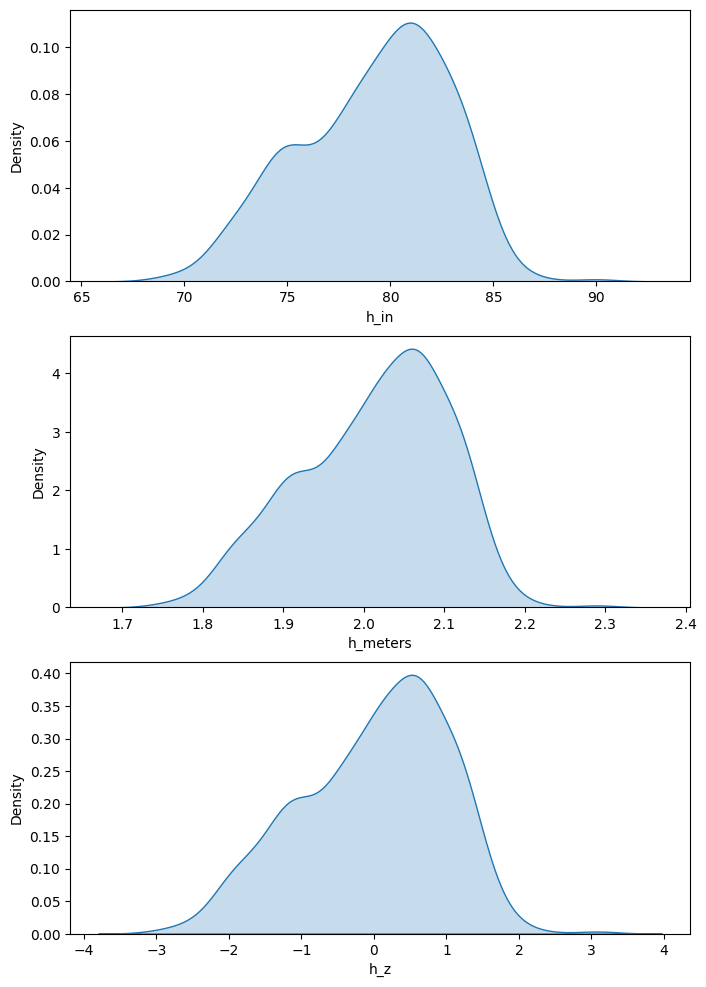

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(8, 12))

sns.kdeplot(df['h_in'], fill=True, ax=ax[0])
sns.kdeplot(df['h_meters'], fill=True, ax=ax[1])
sns.kdeplot(df['h_z'], fill=True, ax=ax[2])

plt.show()

### Other examples of Normal Distribution

Many other things in life follow the same distribution:

- **Biological Measurements**: Beyond height, things like blood pressure, leaf lengths on a tree, or the birth weight of newborns follow this curve.
- **Manufacturing Errors**: If a machine is set to cut `10cm` bolts, most will be exactly `10cm`. A few will be `10.01cm`, and a few `9.99cm`. Extremely rare outliers might be `10.1cm`.
- **Standardized Testing**: Exams like the SAT or IQ tests are *specifically designed* so that the results fall into a normal distribution, allowing scorers to see how an individual compares to the "average" ($\mu$).

### Example 1: Students Scores (Interactive)

iIf students in a math class took a final exam, and the class average was 7.5 out of 10 and the standard deviation was 0.5 points. If the class scores follow a normal distribution, then this means that:

- 68% of the students received a score between 7.0 and 8.0 on the test, or the mean (7.5) plus or minus 1 standard deviation (0.5)
- 95% of students received a grade between 6.5 and 8.5 on the exam, or the mean (7.5) plus or minus 2 standard deviations (1.0)
- 99.7% of students received a grade between 6.0 and 9.0, or the mean (7.5) plus or minor 3 standard deviations

**The following is an interactive example which you can try out to play with the normal distribution**:

- Changing the `mean` would move the `median`, `min` and `max` statistics with it, but won't have an effect on the `range` statistic.
- Changing the `std` would affect the `min` and `max` statistics and consequently, the `range` statstic, but won't have an effect on the `median`.

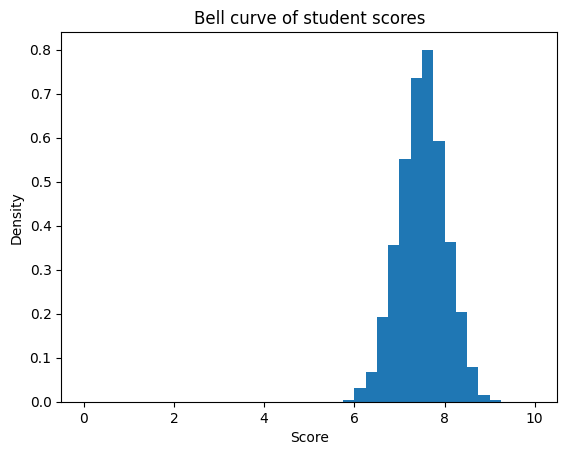

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a NumPy ndarray of 1000 elements sampled from a normal distribution
# with the specified mean and standard deviation.
scores = np.random.normal(
    loc=7.5,   # Mean               << CHANGE THIS
    scale=0.5, # Standard Deviation << CHANGE THIS
    size=1000, # Number of observations
)

# Plot the bell curve of the data.
plt.hist(scores, bins=40, density=True, range=(0, 10))
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Bell curve of student scores")
plt.show()

**Try and Observe**: try changing the mean and standard deviation in the above code to see how normal curve behaves.

### Example 2: Comparative IQ Distribution

**What do you observe about the two overlapping distributions?**

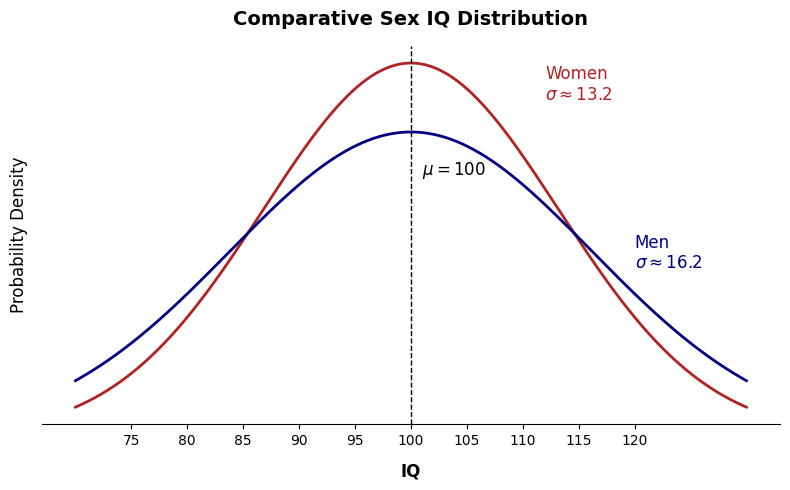

In [70]:
# | echo: false
# | code-fold: true

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the statistical parameters based on new instructions:
mean_iq = 100
std_dev_women = 13.2  # Lower variance (taller, narrower curve than men)
std_dev_men = 16.2    # Higher variance (shorter, wider curve)

# 2. Generate x-axis values (spanning 70 to 130 to cover the image's range)
x = np.linspace(70, 130, 1000)

# 3. Calculate the Probability Density Function (PDF) for both groups
y_women = norm.pdf(x, mean_iq, std_dev_women)
y_men = norm.pdf(x, mean_iq, std_dev_men)

# 4. Initialize the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the curves matching the visual colors
ax.plot(x, y_women, color='firebrick', linewidth=2)
ax.plot(x, y_men, color='navy', linewidth=2)

# Vertical line for the mean
ax.axvline(mean_iq, color='black', linestyle='--', linewidth=1)
ax.text(mean_iq + 1, max(y_women)*0.70, f'$\\mu={mean_iq}$', color='black', fontsize=12)

# Add text labels directly onto the plot (coordinates manually adjusted for fit)
ax.text(112, max(y_women)*0.90, 'Women\n$\\sigma\\approx{}$13.2', 
        color='firebrick', fontsize=12)
ax.text(120, max(y_men)*0.55, 'Men\n$\\sigma\\approx{}$16.2', 
        color='navy', fontsize=12)

# 5. Formatting to match the original image's clean style
ax.set_title('Comparative Sex IQ Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('IQ', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)

# Set the specific x-axis tick marks
ax.set_xticks(range(75, 125, 5))

# Remove y-axis ticks and unnecessary borders to mirror the original figure
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Render the plot
plt.tight_layout()
plt.show()

The figure above shows two **Normal** distributions:

1. with the same **Mean** (center)
2. but different **Standard Deviation** (dispersion).

**Common Misconception**: People often see the red curve is much taller and mistakenly conclude that: "**there are more women in the dataset than men**". Wrong! In reality, the area under the curve represents the total population, not the height of the peak.

Notice that both the red curve (Women) and the blue curve (Men) peak at the same point on the x-axis (IQ ≈ `100`). This indicates that the **mean**, **median**, and **mode** for both groups are approximately equal.

Because the **variance** for men is roughly `5%` to `15%` larger than it is for women, the male distribution curve is wider and flatter, while the female distribution curve is taller and narrower around the middle.

- The Middle: Women are more heavily clustered around the dead-center average (the `85` to `115` IQ range).
- The Extremes: Men are overrepresented at both extremes of the bell curve.

If you look at the extreme right tail of the distribution (an IQ of `140` or higher), the wider male variance means there is a higher ratio of men to women. Conversely, if you look at the extreme left tail (an IQ of `60` or lower), there is also a significantly higher ratio of men to women experiencing severe cognitive deficits.

## Outliers: Out-of-normal

An **Outlier** is an observation which deviates **"too much"** from other observations. Since statistical models look at the group, members that aren't likely of the same group distort these models and affect our calculated statistics, especially when the outliers are exterme and numerous.

We **don't automatically remove** these values, rather, we might want to inspect further to know more about their story.

Deciding how much is "too much" can be done many ways:

1. The **Z-Score method**
2. The **IQR method**
3. others..

### 1. Z-Score Method

The most common one that works well with the *Normal Distribution* is the **Z-score method**, which is calculated by subtracting the mean and dividing by the standard deviation:

$$ z = \frac{x-\mu}{\sigma} $$

Then, we consider any values below and above three standard deviations away as being an *anomaly*, like so:

$$
z \lt -3 \\ 
z \gt +3
$$

More succiently:

$$ \text{Outlier if:} \vert z \vert \gt 3 $$

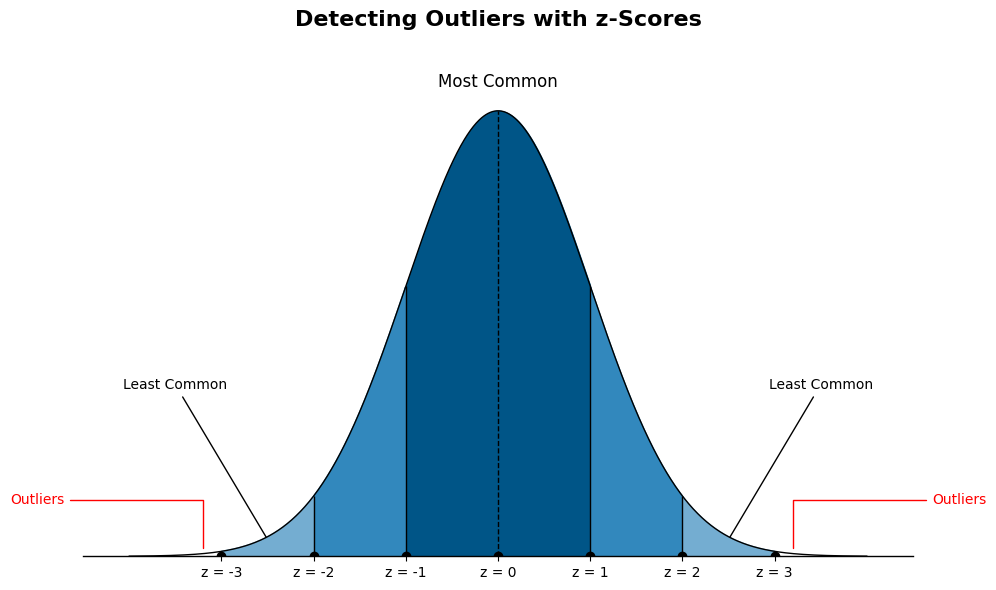

In [71]:
# | echo: false
# | code-fold: true

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Setup Data
z = np.linspace(-4, 4, 1000)
y = norm.pdf(z)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Define Regions and Colors
# Pink: |z| < 1
# Yellow: 1 <= |z| < 2
# Purple: 2 <= |z| < 3
colors = {
    'most': '#005587',
    'common': '#3288bd',
    'least': '#74add1'
}

# Fill regions
ax.fill_between(z, y, where=(np.abs(z) <= 1), color=colors['most'])
ax.fill_between(z, y, where=((np.abs(z) > 1) & (np.abs(z) <= 2)), color=colors['common'])
ax.fill_between(z, y, where=((np.abs(z) > 2) & (np.abs(z) <= 3)), color=colors['least'])

# 3. Plot the Curve and Vertical Lines
ax.plot(z, y, color='black', linewidth=1)
for x_val in [-3, -2, -1, 1, 2, 3]:
    ax.vlines(x_val, 0, norm.pdf(x_val), color='black', linewidth=1)

# Center dashed line
ax.vlines(0, 0, norm.pdf(0), color='black', linestyle='--', linewidth=1)

# 4. Add Dots and X-axis Labels
z_ticks = [-3, -2, -1, 0, 1, 2, 3]
ax.scatter(z_ticks, [0]*7, color='black', zorder=5)
ax.set_xticks(z_ticks)
ax.set_xticklabels([f'z = {v}' for v in z_ticks])

# 5. Annotations (Text and Arrows)
# Main Title
ax.set_title("Detecting Outliers with z-Scores", fontsize=16, fontweight='bold', pad=20)

# "Most Common"
ax.text(0, 0.42, "Most Common", ha='center', fontsize=12)

# "Common" pointers
ax.annotate('Least Common', xy=(-2.5, 0.015), xytext=(-3.5, 0.15),
            arrowprops=dict(arrowstyle='-', color='black'), ha='center')
ax.annotate('Least Common', xy=(2.5, 0.015), xytext=(3.5, 0.15),
            arrowprops=dict(arrowstyle='-', color='black'), ha='center')

# "Outliers" pointers
ax.annotate('Outliers', xy=(-3.2, 0.005), xytext=(-5, 0.05), color='red',
            arrowprops=dict(arrowstyle='-', connectionstyle="angle,angleA=0,angleB=90", color='red'), 
            ha='center', va='center')
ax.annotate('Outliers', xy=(3.2, 0.005), xytext=(5, 0.05), color='red',
            arrowprops=dict(arrowstyle='-', connectionstyle="angle,angleA=0,angleB=90", color='red'), 
            ha='center', va='center')

# 6. Clean up styling
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, 0.45)
ax.set_yticks([]) # Hide Y axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)

plt.tight_layout()
plt.show()

### 2. IQR Method

By convention, a data point may be considered to be an *outlier* if it lies outside of the **Inter-quartile range (IQR)** by more than 1.5 times the IQR. i.e.:

$$
x < Q_1 - 1.5 \times \text{IQR}\\
x > Q_3 + 1.5 \times \text{IQR}
$$

![Box and Whiskers Plot](../../assets/box-and-whiskers_plot.png)

### Box-and-whiskers Plot

A [**boxplot**](https://www.data-to-viz.com/#boxplot) gives a nice summary of one or several numeric variables. The line that divides the box into 2 parts represents the median of the data. The end of the box shows the upper and lower quartiles. The extreme lines show the highest and lowest value excluding outliers.

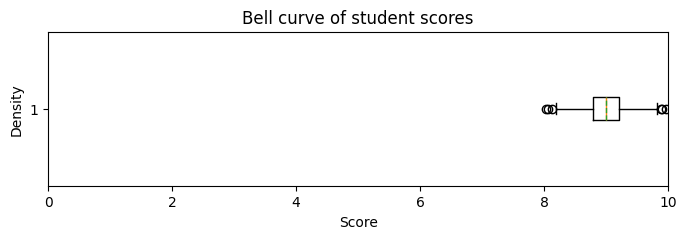

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a NumPy ndarray of 1000 elements sampled from a normal distribution
# with the specified mean and standard deviation.
scores = np.random.normal(
    loc=9.0,   # Mean               <<----------------------------- CHANGE THIS
    scale=0.3, # Standard Deviation <<----------------------------- CHANGE THIS
    size=1000, # Number of observations
)

# Plot the bell curve of the data.
plt.figure(figsize=(8, 2))
plt.boxplot(scores, vert=False, meanline=True, showmeans=True)
plt.xlim(0, 10)
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Bell curve of student scores")
plt.show()

### Comparing IQR & Z-score methods

We notice that the IQR-method is more conservative; i.e., **flags more outliers** compared to the z-score method.

![](../assets/boxplot_vs_normal.png)

## Interpreting Distributions

Let's go back to our comparison: NBA Players vs General Public in terms of Height.

Below are the distributions of height in centimeters across:

- Adult women globally (mean of `159cm` and standard deviation of `6cm`)
- Adult men globally (mean of `171cm` and standard deviation of `7cm`)
- NBA players; a specific subset of adult men (~2300 players who have been part of an NBA team roster between 1996 and 2019)

Let's visualize it:

![Comparative Distribution of NBA Player's Heights and Human Heights. Image Source: https://distributionofthings.com/human-height/](../../assets/nba_comparative_distribution.png)


The figure above shows

- three **Normal** distributions
- with increasing centers (as we go right)
- and decreasing dispersino (as we go right)

Using statistics we can make **General Statements** like:

1. "men are taller than women" (on average is implied)
2. "most NBA players are taller than most people"
3. "most NBA players are men"
4. "very few women are taller than the shortest NBA players"

Notice that since there are overlaps, we can't give **Definitive Statements** like:

- "All men are ... " (confirmatory)
- "No Player is ..." (negation)

### Interpreting Outliers

When having outliers in one distribution, that might signal to us that it is, in fact, a member of another distribution. In this case:

- a Male with a height of `+192cm` might be an **outlier within Males**, but
- that's within the normal distribution of **NBA Players**

If you want to read more about human height, its evolution across the world and predictions for the future I encourage you to check out this great [article from Our World in Data](https://ourworldindata.org/human-height).

## Variations of Distribution Plots

### Variation 1: Mirror Histogram

A common variation of the histogram is the [**mirror histogram**](https://python-graph-gallery.com/density-mirror/): it puts face to face 2 histograms to compare their distribution.

![](../assets/population_pyramid.png)

See: [Population Pyramid | DataSaudi.sa](https://datasaudi.sa/en#population-pyramid)

### Variation 2: Ridgeline Plot

A [**Ridgeline plot**](https://www.data-to-viz.com/graph/ridgeline.html) (sometimes called **Joyplot**) shows the distribution of a numeric value for several groups. Distribution can be represented using histograms or density plots, all aligned to the same horizontal scale and presented with a slight overlap.

![Ridge Plot of Temperature in Lincoln NE in 2016](../../assets/ridgeplot_temperature_in_lincoln_ne_in_2016.png){height=480}

## Other Distributions

![Histogram Distributions](../../assets/histogram_distributions.png){height=600}

We describe the distribtuion using these vocabularies:

1. Normal: symmetric triangle
2. Uniform: even, like a brush
3. Left-skewed: right-angle triangle
4. Right-skewed: left-angle triangle
5. Bimodal: two normals together
6. Multi-modal: many normals together

### Example: Exponential Distribution

Distrubtion of Death by Age in Australia in the Year 2012.

![Deaths in Australia in the year 2012](../../assets/deaths-in-australia-in-the-year-2012.png){height=480}


The figure above shows a **left-tailed exponential distribution**.

The graph shows "Deaths in Australia in the year 2012." This is an excellent example of a **Negatively Skewed (Left-Skewed)** distribution.

* **Direction of Skew:** A distribution is named by the direction of its "tail." Here, the tail extends toward the younger age brackets (the left). This indicates that while most people die at older ages, a smaller number of "outliers" die much younger, pulling the average down.
* **The Relationship Between Mean, Median, and Mode:** In a perfectly symmetrical curve, these three would be the same. However, in a skewed distribution, they pull apart:
    * **Mode (~87 years):** The "most frequent" age of death, represented by the highest peak.
    * **Median (~81 years):** The middle value; 50% of people died before this age, and 50% after.
    * **Mean (~77 years):** The arithmetic average. It is the most affected by the "tail." Because some people die very young (ages 0–40), the mean is pulled significantly lower than the mode.
* **Insight:** When data is skewed, the **Median** is often a better "typical" representation of the data than the Mean, because the Mean is overly sensitive to extreme outliers (infant mortality or early-life accidents).

### Other Examples

See the blog: [**Distribution of Things**](https://distributionofthings.com/).